# Evaluation: Baseline vs Smart Bots Under Move Budgets

This notebook compares the DFS baseline bot against three smart bots (RF, GBT, GP) on four held-out eval mazes across move budget settings from 20 to 42 moves and an unlimited run. 

**The central question**: does restricting available moves expose smart bots' reward-ordering advantage over pure DFS, and where does the advantage disappear?

- *Eval mazes*: Gradius Pathways, O Contra, Glasses, Reverse  
- *Budget settings*: all `*.json` files from `data/eval_runs/`, one file per budget (20, 22, …, 42) plus `eval_inf.json` (unlimited)

## Setup and Load Results

In [23]:
import importlib
import json
from pathlib import Path
from typing import Any, Literal, Optional, cast

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D

import style
importlib.reload(style)
style.apply()

from maze_kluster.bots.base import RunResult
from maze_kluster.metrics import (
    collection_rate,
    exploration_completeness,
    score_efficiency,
    step_efficiency,
)

OUT = Path("../docs/sphinx/res/analysis/evaluate")
OUT.mkdir(parents=True, exist_ok=True)

EVAL_MAZE_META: dict[str, dict[str, int]] = {
    "Gradius Pathways": {"total_tiles": 26, "potential_reward": 232},
    "O Contra":         {"total_tiles": 26, "potential_reward": 196},
    "Glasses":          {"total_tiles": 30, "potential_reward": 272},
    "Reverse":          {"total_tiles": 30, "potential_reward": 236},
}

eval_dir = Path("../data/eval_runs")
raw: list[dict[str, Any]] = []
for path in sorted(eval_dir.glob("*.json")):
    records: list[dict[str, Any]] = json.loads(path.read_text())
    raw.extend(records)
    budget = records[0].get("max_moves", "unlimited") if records else "?"
    print(f"  {path.name}: {len(records)} records  (max_moves={budget})")

print(f"\nTotal: {len(raw)} records")
print("Budgets:", sorted(r["max_moves"] for r in raw if r.get("max_moves") is not None))
print("Mazes:",   sorted({r["maze"] for r in raw}))
print("Bots:",    sorted({r["bot"] for r in raw}))

  eval_inf.json: 16 records  (max_moves=None)
  eval_mm20.json: 16 records  (max_moves=20)
  eval_mm22.json: 16 records  (max_moves=22)
  eval_mm24.json: 16 records  (max_moves=24)
  eval_mm26.json: 16 records  (max_moves=26)
  eval_mm28.json: 16 records  (max_moves=28)
  eval_mm30.json: 16 records  (max_moves=30)
  eval_mm32.json: 16 records  (max_moves=32)
  eval_mm34.json: 16 records  (max_moves=34)
  eval_mm36.json: 16 records  (max_moves=36)
  eval_mm38.json: 16 records  (max_moves=38)
  eval_mm40.json: 16 records  (max_moves=40)
  eval_mm42.json: 16 records  (max_moves=42)

Total: 208 records
Budgets: [20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 

In [24]:
def _to_run_result(record: dict[str, Any]) -> RunResult:
    return RunResult(
        maze_name=str(record["maze"]),
        score_in_bag=float(record["score_in_bag"]),
        score_lost=float(record["score_lost"]),
        total_moves=int(record["total_moves"]),
        tiles_visited=int(record["tiles_visited"]),
        total_tiles=int(record["total_tiles"]),
        potential_reward=float(record["potential_reward"]),
    )


rows = []
for rec in raw:
    result = _to_run_result(rec)
    mm = rec.get("max_moves")
    rows.append({
        "maze": result.maze_name,
        "bot": str(rec["bot"]),
        "max_moves": mm,
        "budget": str(mm) if mm is not None else "unlimited",
        "score_efficiency": score_efficiency(result),
        "step_efficiency": step_efficiency(result),
        "collection_rate": collection_rate(result),
        "exploration_completeness": exploration_completeness(result),
        "score_in_bag": result.score_in_bag,
        "potential_reward": result.potential_reward,
        "total_moves": result.total_moves,
        "tiles_visited": result.tiles_visited,
    })

metrics_df = pd.DataFrame(rows)
metrics_df = metrics_df.sort_values(["max_moves", "maze", "bot"]).reset_index(drop=True)

BOT_ORDER = ["baseline", "rf", "gbt", "gp"]
MAZE_ORDER = sorted(EVAL_MAZE_META, key=lambda m: EVAL_MAZE_META[m]["potential_reward"])
BUDGETS = sorted(metrics_df["max_moves"].dropna().unique().astype(int).tolist())
PALETTE: dict[str, str] = style.BOT_PALETTE
MARKERS: dict[str, str] = {"baseline": "o", "rf": "s", "gbt": "^", "gp": "D"}
LINESTYLES: dict[str, Literal["-", "--", "-.", ":"]] = {
    "baseline": "-", "rf": "--", "gbt": "-.", "gp": ":"
}

print(f"Budgets in data: {BUDGETS}")
metrics_df[["maze", "bot", "budget", "score_efficiency", "step_efficiency", "total_moves"]].head(12)

Budgets in data: [20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42]


,maze,bot,budget,score_efficiency,step_efficiency,total_moves
0,Glasses,baseline,20,0.595588,4.500000,36
1,Glasses,gbt,20,1.000000,4.000000,68
2,Glasses,gp,20,1.000000,4.000000,68
3,Glasses,rf,20,1.000000,4.000000,68
4,Gradius Pathways,baseline,20,0.655172,4.750000,32
5,Gradius Pathways,gbt,20,1.000000,6.444444,36
6,Gradius Pathways,gp,20,0.870690,6.733333,30
7,Gradius Pathways,rf,20,1.000000,5.800000,40
8,O Contra,baseline,20,0.642857,5.040000,25
9,O Contra,gbt,20,0.846939,6.148148,27


## Score Efficiency by Budget

Score efficiency pivot: rows = (maze, bot), columns = budget setting.  
Values below 1.0 are the interesting cases where the budget cut a bot short.

In [25]:
pivot = metrics_df.pivot_table(
    index=["maze", "bot"],
    columns="budget",
    values="score_efficiency",
).reindex(
    pd.MultiIndex.from_product([MAZE_ORDER, BOT_ORDER], names=["maze", "bot"])
).round(3)

pivot.columns.name = "budget (max_moves)"
pivot

budget (max_moves)            20     22     24     26     28     30     32  \
maze             bot                                                         
O Contra         baseline  0.643  0.745  0.847  0.847  0.847  0.847  0.898   
                 rf        0.541  0.643  0.745  0.847  0.847  0.847  0.847   
                 gbt       0.847  0.847  0.847  0.847  0.847  0.847  0.847   
                 gp        1.000  1.000  1.000  1.000  1.000  1.000  1.000   
Gradius Pathways baseline  0.655  0.741  0.784  0.784  0.871  0.957  0.957   
                 rf        1.000  1.000  1.000  1.000  1.000  1.000  1.000   
                 gbt       1.000  1.000  1.000  1.000  1.000  1.000  1.000   
                 gp        0.871  0.871  0.871  0.871  0.871  0.914  1.000   
Reverse          baseline  1.000  1.000  1.000  1.000  1.000  1.000  1.000   
                 rf        0.992  0.992  0.992  0.992  0.992  0.992  0.992   
                 gbt       1.000  1.000  1.000  1.000  1.000  1.000  1.000   
                 gp        0.992  0.992  0.992  0.992  0.992  0.992  0.992   
Glasses          baseline  0.596  0.669  0.779  0.779  0.779  0.779  0.779   
                 rf        1.000  1.000  1.000  1.000  1.000  1.000  1.000   
                 gbt       1.000  1.000  1.000  1.000  1.000  1.000  1.000   
                 gp        1.000  1.000  1.000  1.000  1.000  1.000  1.000   

budget (max_moves)            34     36     38     40     42  unlimited  
maze             bot                                                     
O Contra         baseline  0.949  1.000  1.000  1.000  1.000        1.0  
                 rf        0.898  0.949  1.000  1.000  1.000        1.0  
                 gbt       0.898  0.949  1.000  1.000  1.000        1.0  
                 gp        1.000  1.000  1.000  1.000  1.000        1.0  
Gradius Pathways baseline  1.000  1.000  1.000  1.000  1.000        1.0  
                 rf        1.000  1.000  1.000  1.000  1.000        1.0  
                 gbt       1.000  1.000  1.000  1.000  1.000        1.0  
                 gp        1.000  1.000  1.000  1.000  1.000        1.0  
Reverse          baseline  1.000  1.000  1.000  1.000  1.000        1.0  
                 rf        0.992  0.992  0.992  0.992  0.992        1.0  
                 gbt       1.000  1.000  1.000  1.000  1.000        1.0  
                 gp        0.992  0.992  0.992  0.992  0.992        1.0  
Glasses          baseline  0.853  0.926  1.000  1.000  1.000        1.0  
                 rf        1.000  1.000  1.000  1.000  1.000        1.0  
                 gbt       1.000  1.000  1.000  1.000  1.000        1.0  
                 gp        1.000  1.000  1.000  1.000  1.000        1.0

#### Conclusion

- **`Glasses` maze has consistent smart bot advantage**: all three smart bots maintain score_efficiency = 1.0 at every budget from 20 upward; the baseline scores as low as 0.60 at budget 20 and does not reach 1.0 until budget 38. This is the clearest separation in the dataset.
- **`Gradius` Pathways maze have RF and GBT dominate throughout**: RF and GBT hold 1.0 at all budgets; GP catches up at budget 32; baseline needs 34 moves to clear all reward. Smart bots have a persistent 8–12 move advantage here.
- **`O Contra` maze has DFS outperforms RF and GBT at tight budgets**: baseline clears `O Contra` by budget 36; RF and GBT do not reach 1.0 until budget 38. GP is the exception, achieving 1.0 at every budget. Smart bots' reward predictions can misroute on specific maze topologies.
- **`Reverse` maze has a 2-point persistent loss for RF and GP**: RF and GP score 234/236 (0.992) at every finite budget; the loss vanishes only at unlimited. GBT and DFS achieve 1.0 at all settings. This is not a budget artefact, but reflects these models deprioritising specific collectible tile(s).
- **Convergence at budget 38**: from budget 38 onward all bots reach 1.0 on all mazes except the `Reverse` maze with outkiers on the RF/GP bots. The "interesting zone" where bots diverge is budgets 20–36.

## Score Efficiency vs Move Budget

2x2 grid with one heatmap per maze. 
- Rows = bots, columns = move budgets 20–42. 
- Cell colour and annotation = score_efficiency.
- **Green = 1.0** (bot collected all reward within budget). 
- **Red = budget cut the bot short**. 

Reading across a row shows how a bot improves as budget relaxes; reading down a column shows which bots are most constrained at a given budget.

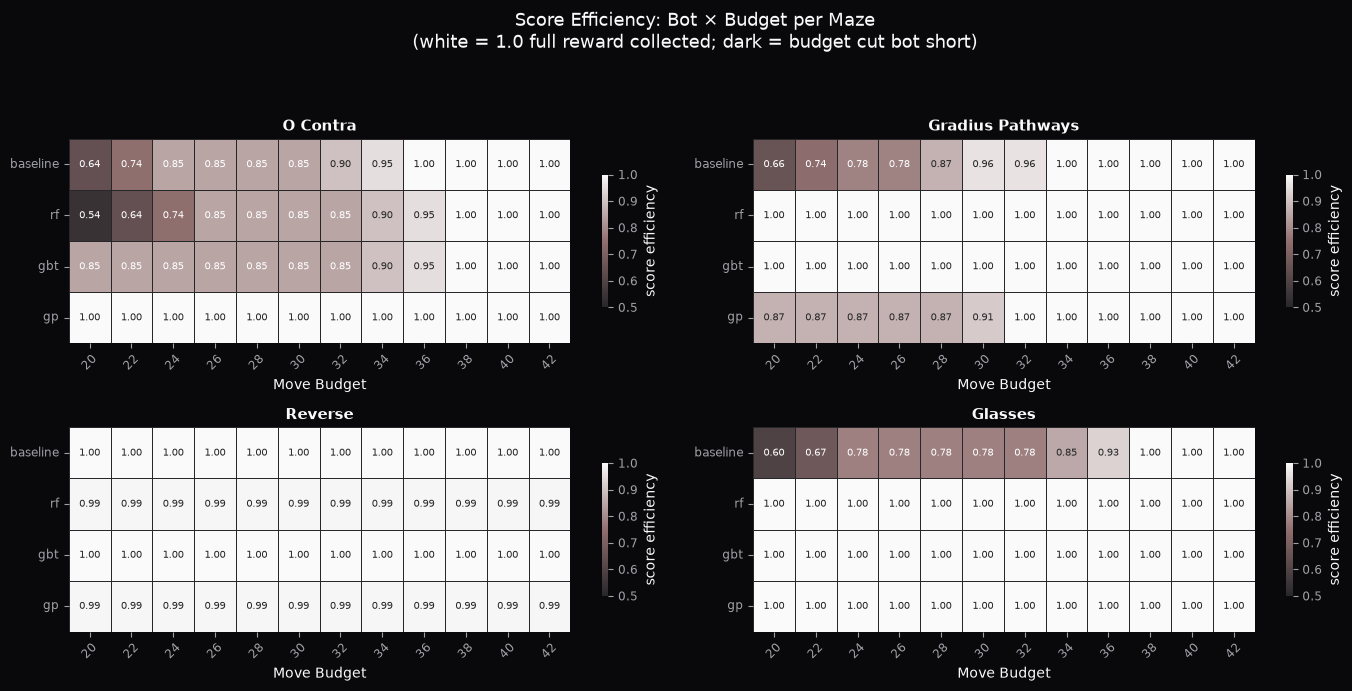

In [26]:
finite_df = metrics_df[metrics_df["max_moves"].notna()].copy()
finite_df["max_moves"] = finite_df["max_moves"].astype(int)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes_flat = axes.flatten()

for i, maze in enumerate(MAZE_ORDER):
    ax = axes_flat[i]
    sub = finite_df[finite_df["maze"] == maze]
    pivot = sub.pivot_table(index="bot", columns="max_moves", values="score_efficiency")
    pivot = pivot.reindex(BOT_ORDER)

    sns.heatmap(
        pivot, ax=ax,
        cmap=style.score_cmap(), vmin=0.5, vmax=1.0,
        annot=True, fmt=".2f", annot_kws={"size": 7.5},
        linewidths=0.4, linecolor=style.BORDER,
        cbar_kws={"shrink": 0.65, "label": "score efficiency"},
    )
    ax.set_title(maze)
    ax.set_xlabel("Move Budget")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Score Efficiency: Bot × Budget per Maze\n(white = 1.0 full reward collected; dark = budget cut bot short)",
    fontsize=13,
)
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.savefig(OUT / "score-efficiency-bot-x-budget-per-maze.svg")
plt.show()

#### Conclusion

With budgets ranging from 20 to 42, the charts reveal a clear crossover pattern:

- **`Glasses` is the strongest case for smart bots**: RF, GBT, and GP maintain 1.0 at every budget point while baseline climbs from 0.60 at budget 20, only reaching 1.0 at budget 38. The 18-budget-move gap demonstrates how distance-aware reward scoring routes smart bots to the high-value tile cluster before the DFS traversal reaches it.
- **`Gradius Pathways` reinforces this**: RF and GBT hold 1.0 throughout; GP reaches it by budget 32; baseline needs 34. The reward cluster in `Gradius` lies far from the DFS natural traversal order, so a model that scores tiles by predicted reward reaches it earlier.
- **`O Contra` inverts the story**: DFS achieves 1.0 at budget 36 while RF and GBT do not until budget 38. GP is the sole model that maintains 1.0 at all budget values on this maze. The RF and GBT models misroute on this topology where their frontier scoring sends them to the far end of the maze first, leaving a collectible unreached when force_exit fires.
- **`Reverse` is an anomaly**: RF and GP consistently score 234/236 at every finite budget. This is not a budget effect but because the models deprioritise a specific collectible regardless of available moves. Only at unlimited budget does this resolve.
- **At budget 38 and above**, all bots achieve 1.0 on all mazes (excluding the `Reverse` RF/GP structural outlier). The active competition zone is budgets 20–36.

## Budget Adherence: Actual Moves Used vs Budget Setting

How strongly does the budget actually constrain each bot's move count? A flat line (same moves across all budgets) means the bot ignores the budget and its natural traversal already finishes before or well after the limit. 

A downward slope means the budget is actively cutting the bot short (and usually comes with a score penalty).

The dashed diagonal (`y = x`) marks the point where actual moves equal the budget exactly.

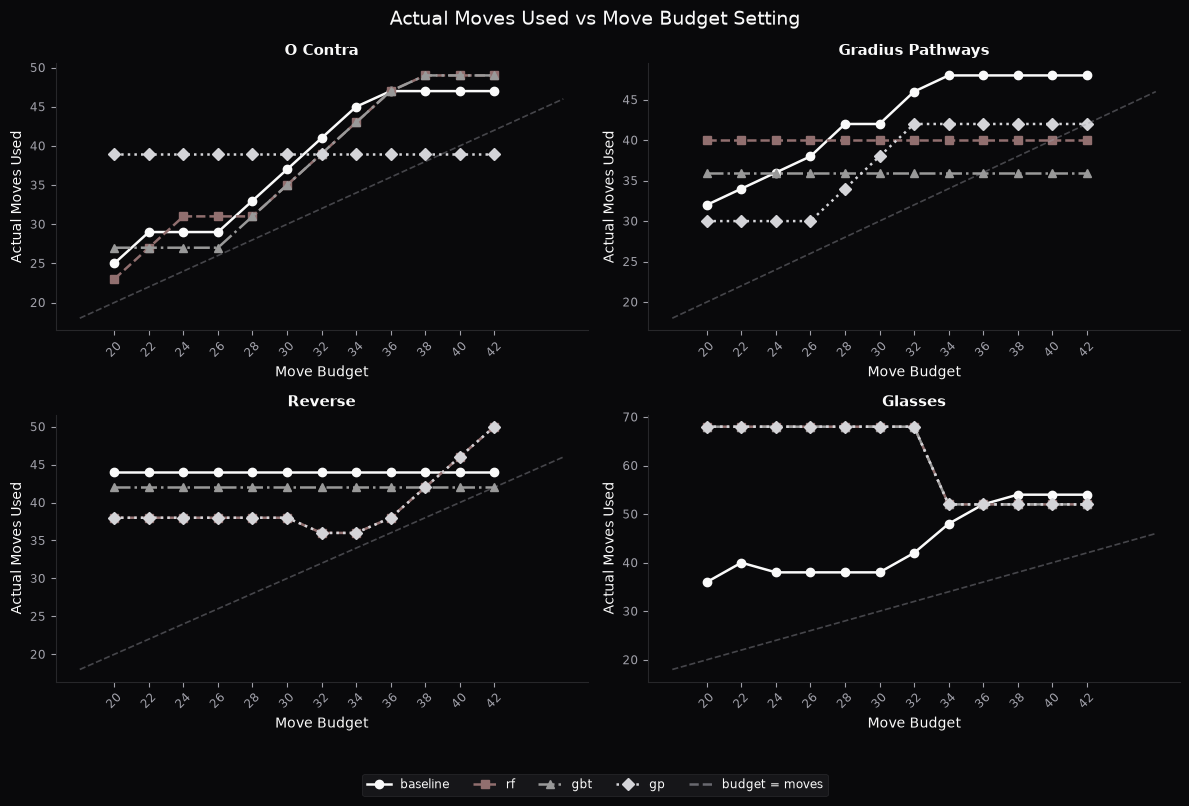

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes_flat = axes.flatten()

for i, maze in enumerate(MAZE_ORDER):
    ax = axes_flat[i]
    sub = metrics_df[metrics_df["maze"] == maze]
    for bot in BOT_ORDER:
        bot_data = sub[sub["bot"] == bot].sort_values("max_moves")
        if bot_data.empty:
            continue
        ax.plot(
            bot_data["max_moves"], bot_data["total_moves"],
            marker=MARKERS[bot], linestyle=LINESTYLES[bot],
            color=PALETTE[bot], label=bot, linewidth=1.8,
        )
    if BUDGETS:
        b_min, b_max = BUDGETS[0] - 2, BUDGETS[-1] + 4
        ax.plot([b_min, b_max], [b_min, b_max], linestyle="--", color=style.MUTED, alpha=0.4, linewidth=1.2)
        ax.set_xticks(BUDGETS)
        ax.tick_params(axis="x", rotation=45)
    ax.set_title(maze)
    ax.set_xlabel("Move Budget")
    ax.set_ylabel("Actual Moves Used")

handles = [
    Line2D([0], [0], color=PALETTE[b], marker=MARKERS[b], linestyle=LINESTYLES[b], label=b)
    for b in BOT_ORDER
]
handles.append(Line2D([0], [0], color=style.MUTED, linestyle="--", alpha=0.6, label="budget = moves"))
fig.legend(handles=handles, loc="lower center", ncol=5, title="", bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Actual Moves Used vs Move Budget Setting", fontsize=14)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.savefig(OUT / "actual-moves-used-vs-move-budget-setting.svg")
plt.show()

#### Conclusion

Lines above the diagonal mean the bot used more moves than the budget. In this case *force_exit* fired but the bot still had to travel to the exit, adding overhead. No bot ever exits in fewer moves than its budget.

- **Baseline on `Glasses` maze**: the actual-moves line rises with budget as DFS explores more tiles before *force_exit* fires. The score penalty at tight budgets (chart above) corresponds to exactly the extra tiles DFS cannot reach in time.
- **GBT on `Gradius` maze**: near-flat line close to the diagonal at tight budgets meaning the budget is tight enough to fire but GBT has already collected everything worth collecting by then. This is the ideal outcome: move budget ~= natural traversal length.
- **Smart bots on `O Contra` and `Reverse` mazes**: use **more** moves than DFS at the same budget. Their frontier ordering routes them via longer paths to reach predicted high-reward tiles, which is not more efficient on these maze topologies.
- **As budget increases**, all lines flatten and the budget stops being a binding constraint and bots complete their natural traversal regardless of the setting.

## Feature Importances (RF)

Horizontal bar chart of Random Forest feature importances. 

GBT and GP do not expose `feature_importances_`, so this is RF-only.  

**Hypothesis**: `neighbor_reward_mean` should be the strongest signal because reward is spatially clustered. Knowing the average reward of adjacent tiles is a good proxy for a tile's own value. Structural features (`actual_degree`, `is_dead_end`) are expected to contribute secondary signal.

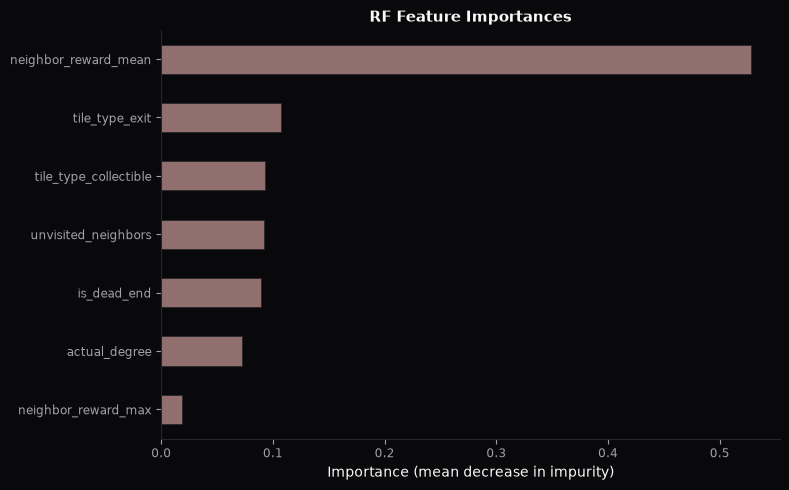

Top features:
neighbor_reward_mean     0.527526
tile_type_exit           0.107462
tile_type_collectible    0.092638
dtype: float64


In [28]:
import os
from maze_kluster.models.rf import RFScorer

_orig_cwd = os.getcwd()
os.chdir("..")
rf_scorer = RFScorer.load()
os.chdir(_orig_cwd)

importances = rf_scorer.feature_importances()

imp_series = pd.Series(importances).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
imp_series.plot(kind="barh", ax=ax, color=style.BROWN, edgecolor=style.BORDER)
ax.set_title("RF Feature Importances")
ax.set_xlabel("Importance (mean decrease in impurity)")
plt.tight_layout()
plt.savefig(OUT / "rf-feature-importances.svg")
plt.show()

print("Top features:")
print(imp_series.sort_values(ascending=False).head(3))

#### Conclusion

The result partially confirms the hypothesis, with one clear correction:

- **`neighbor_reward_mean` dominates at ~0.53** where the average reward of a tile's already-known neighbours is by far the strongest predictor. This confirms the spatial clustering assumption: if surrounding tiles are rewarding, the target tile probably is too.
- **`tile_type_exit` is second at ~0.11**, which was not predicted. The model learned that exit tiles carry a distinctive reward signature, likely because the exit is structurally near high-value zones in the training mazes.

The model's core logic is a locally-smooth reward assumption: average neighbourhood value predicts tile value well. The maximum neighbour value, by contrast, is not reliably informative beyond what the mean already captures.

## Step Efficiency Across Budgets

Step efficiency (reward per move) shows how densely each bot earns reward relative to moves spent. 

2x2 panel with one subplot per maze.
- *x-axis = move budget*
- *y-axis = step efficiency*.

Under tighter budgets, a bot that exits early with incomplete score can show *lower* step efficiency as it collects less reward but also uses fewer moves. Read alongside score efficiency to distinguish "collected less" from "moved more efficiently".

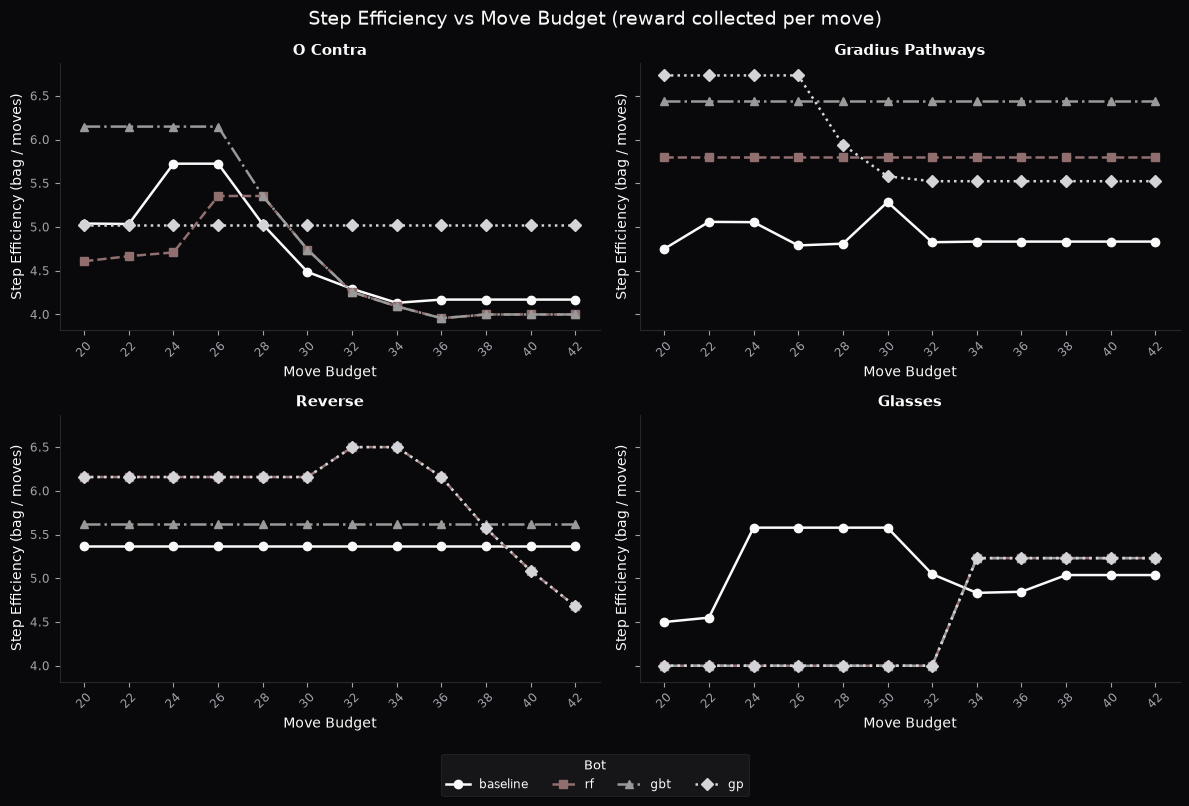

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes_flat = axes.flatten()

for i, maze in enumerate(MAZE_ORDER):
    ax = axes_flat[i]
    sub = metrics_df[metrics_df["maze"] == maze]
    for bot in BOT_ORDER:
        bot_data = sub[sub["bot"] == bot].sort_values("max_moves")
        if bot_data.empty:
            continue
        ax.plot(
            bot_data["max_moves"], bot_data["step_efficiency"],
            marker=MARKERS[bot], linestyle=LINESTYLES[bot],
            color=PALETTE[bot], label=bot, linewidth=1.8,
        )
    ax.set_title(maze)
    ax.set_xlabel("Move Budget")
    ax.set_ylabel("Step Efficiency (bag / moves)")
    if BUDGETS:
        ax.set_xticks(BUDGETS)
        ax.tick_params(axis="x", rotation=45)

handles = [
    Line2D([0], [0], color=PALETTE[b], marker=MARKERS[b], linestyle=LINESTYLES[b], label=b)
    for b in BOT_ORDER
]
fig.legend(handles=handles, loc="lower center", ncol=4, title="Bot", bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Step Efficiency vs Move Budget (reward collected per move)", fontsize=14)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.savefig(OUT / "step-efficiency-vs-move-budget.svg")
plt.show()

### Conclusion

Step efficiency (reward / move) rises or stays the same with budget for most bots as the budget stops constraining them, then plateaus once the natural traversal length is reached. The 2x2 view across mazes shows how maze-specific this metric is:

- **`Glasses` maze**: smart bots achieve consistently higher step efficiency than baseline across the full budget range. GBT and RF collect all 272 points in ~52 moves vs DFS's 54 (at unlimited), so they earn slightly more per step.
- **`Gradius Pathways` maze**: RF and GBT show the highest step efficiency because they collect full reward (232 points) in 36–40 moves vs DFS's 48 at unlimited. The step-efficiency lines for RF/GBT are notably above DFS at loose budgets, reflecting a genuinely more compact traversal on this maze.
- **`O Contra` maze**: DFS step efficiency is competitive or superior to RF and GBT across much of the budget range where those bots misroute and collect fewer points per move. GP is the best performer, collecting all 196 points in only 39 moves at unlimited.
- **`Reverse` maze**: GBT and DFS match each other across all budgets. RF and GP slightly underperform due to the 2-point collectible anomaly at finite budgets, and both use 60 moves at unlimited (vs DFS's 44), making their step efficiency on Reverse the worst in the dataset.

## Score vs Moves Trade-off

Each point is one (bot, maze, budget) run. 
- *x-axis = actual moves used*
- *y-axis = score efficiency* 
- *Top-left is ideal: high score with few moves.* 
- *Color and shape = bot* 
- *dot size @ move budget (small = tight, large = loose)*
- *black outline = unlimited run.*

The scatter plots shows all 208 (bot, maze, budget) data points plus 16 unlimited runs in one efficiency-vs-moves view. 

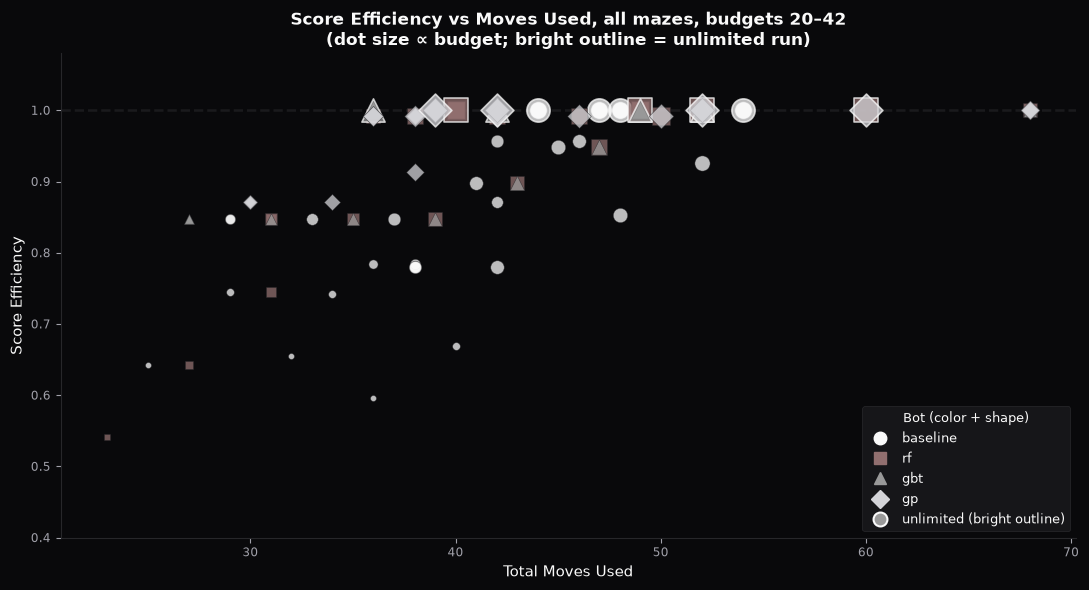

In [30]:
import math

_budget_idx = {b: i for i, b in enumerate(BUDGETS)}


def _dot_size(mm: Optional[float]) -> float:
    if mm is None or math.isnan(mm):
        return 280
    return 18 + _budget_idx.get(int(mm), 0) / max(len(BUDGETS) - 1, 1) * 140


fig, ax = plt.subplots(figsize=(11, 6))

for bot in BOT_ORDER:
    for _, row in metrics_df[metrics_df["bot"] == bot].iterrows():
        mm = cast(Optional[float], row["max_moves"])
        is_unlimited = mm is None or math.isnan(mm)
        ax.scatter(
            row["total_moves"], row["score_efficiency"],
            color=PALETTE[bot], marker=MARKERS[bot],
            s=_dot_size(mm), alpha=0.75, zorder=3,
            edgecolors=style.TEXT if is_unlimited else style.BORDER,
            linewidths=1.2 if is_unlimited else 0.4,
        )

ax.set_xlabel("Total Moves Used", fontsize=11)
ax.set_ylabel("Score Efficiency", fontsize=11)
ax.set_ylim(0.40, 1.08)
ax.axhline(1.0, color=style.BORDER, linestyle="--", alpha=0.6)
ax.set_title(
    "Score Efficiency vs Moves Used, all mazes, budgets 20–42\n"
    "(dot size ∝ budget; bright outline = unlimited run)",
    fontsize=12,
)

bot_handles = [
    Line2D([0], [0], color=PALETTE[b], marker=MARKERS[b], linestyle="", markersize=9, label=b)
    for b in BOT_ORDER
]
inf_handle = Line2D(
    [0], [0], color=style.GRAY, marker="o", linestyle="", markersize=10,
    markeredgecolor=style.TEXT, markeredgewidth=1.5, label="unlimited (bright outline)",
)
ax.legend(handles=bot_handles + [inf_handle], loc="lower right", title="Bot (color + shape)", fontsize=9)
plt.tight_layout()
plt.savefig(OUT / "score-efficiency-vs-moves-used-per-budget.svg")
plt.show()

#### Conclusion

- **Top cluster (y ~= 1.0)**: For the vast majority of points most bots collect full reward once the budget is loose enough. The spread on the x-axis at y=1.0 shows the range of move counts bots use to achieve perfect efficiency.
- **Below-1.0 points** are concentrated at small dot sizes (tight budgets): baseline on `Glasses`/`Gradius` at budget 20–34, and RF/GBT on `O Contra` at budget 20–36. These are the scenarios where the budget cuts the run short before all collectibles are reached.
- **Unlimited runs (black outlines)** cluster at y=1.0 at varying x positions. GP and RF on `Reverse` appear at x=60 with 16+ moves beyond DFS's natural 44-move traversal. These are the largest-move, perfect-score runs in the dataset, illustrating smart bots its backtracking overhead without budget pressure.
- **GBT triangles** at x=36 (`Gradius`, unlimited) and x=42 (`Reverse`, unlimited) sit among the leftmost perfect-score points, confirming GBT as the most move-efficient smart bot across most mazes.

## Exploration Completeness

2x2 grid of line diagrams with one subplot per maze
- *x-axis = move budget*
- *`tiles_visited / total_tiles` per (maze, bot, budget)* 

Under a tight move budget, bots may force-exit before visiting all tiles. 

**Caveat**: `exploration_completeness` is capped at 1.0. Portal mazes can accumulate more coordinate pairs than `total_tiles` in the graph; the cap prevents values > 1.0 from appearing.

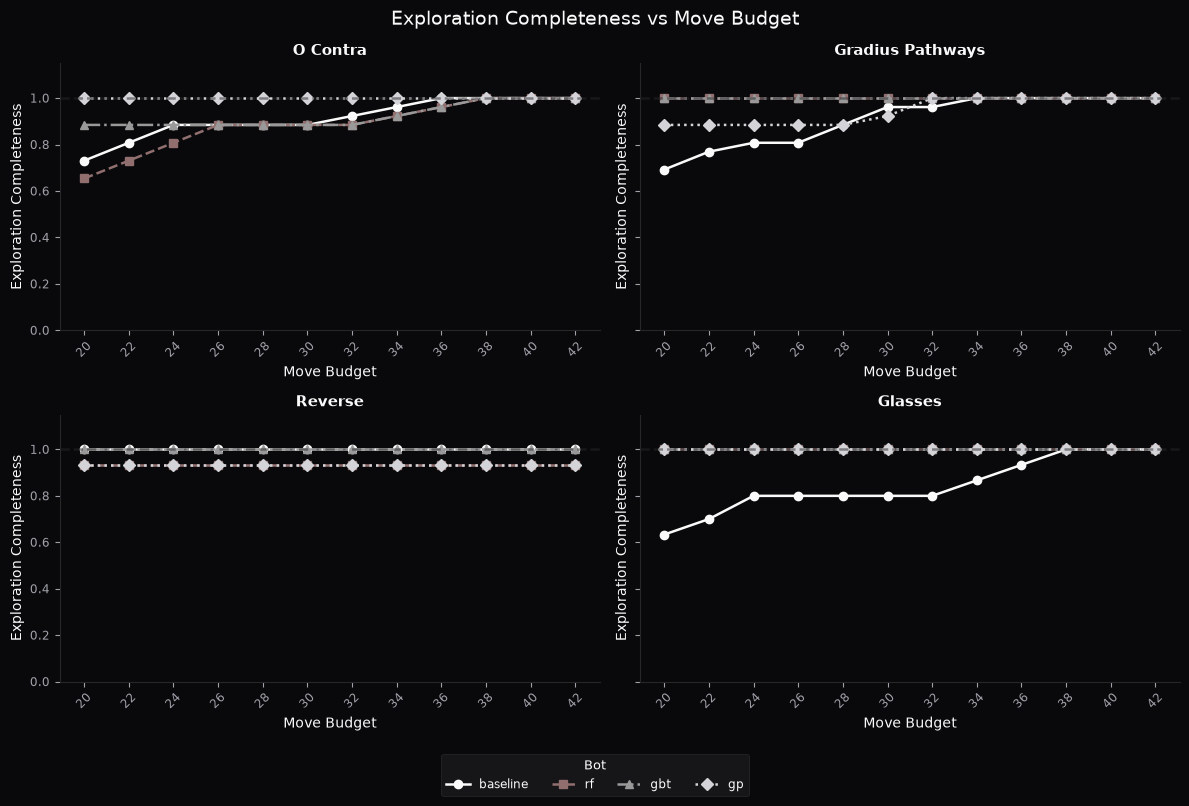

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes_flat = axes.flatten()

for i, maze in enumerate(MAZE_ORDER):
    ax = axes_flat[i]
    sub = metrics_df[metrics_df["maze"] == maze]
    for bot in BOT_ORDER:
        bot_data = sub[sub["bot"] == bot].sort_values("max_moves")
        if bot_data.empty:
            continue
        ax.plot(
            bot_data["max_moves"], bot_data["exploration_completeness"],
            marker=MARKERS[bot], linestyle=LINESTYLES[bot],
            color=PALETTE[bot], label=bot, linewidth=1.8,
        )
    ax.set_title(maze)
    ax.set_xlabel("Move Budget")
    ax.set_ylabel("Exploration Completeness")
    ax.axhline(1.0, color=style.BORDER, linestyle="--", alpha=0.5)
    ax.set_ylim(0, 1.15)
    if BUDGETS:
        ax.set_xticks(BUDGETS)
        ax.tick_params(axis="x", rotation=45)

handles = [
    Line2D([0], [0], color=PALETTE[b], marker=MARKERS[b], linestyle=LINESTYLES[b], label=b)
    for b in BOT_ORDER
]
fig.legend(handles=handles, loc="lower center", ncol=4, title="Bot", bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Exploration Completeness vs Move Budget", fontsize=14)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.savefig(OUT / "exploration-completeness-vs-move-budget.svg")
plt.show()

#### Conclusion

Exploration completeness rises with budget as more tiles are visited before force_exit fires. The shape of each line mirrors the score_efficiency chart closely where bots that score poorly at tight budgets also explore fewer tiles.

- **Baseline on `Glasses`**: the steepest rise from budget 20 to 38. At budget 20 DFS exits before visiting significant portions of the maze; by budget 38 it reaches 1.0. This is the most dramatic exploration gap in the dataset.
- **Smart bots on `Glasses`**: flat at 1.0 from budget 20, they visit the entire maze graph even at the tightest budget. Their reward ordering routes them efficiently through the maze without leaving tiles unvisited.
- **`O Contra`**: all bots reach completeness = 1.0 by budget 38 at the latest. The exploration deficit at tight budgets is smaller here than on `Glasses` where `O Contra` its layout means even DFS covers most tiles early.
- **`Gradius` and `Reverse`**: completeness is 1.0 or near-1.0 for all bots at all budgets, consistent with the score_efficiency results showing those mazes are well-covered even at tight settings.

## Unlimited Budget: How Bots Behave Without Move Constraints

When `max_moves=None`, force_exit never fires. Bots explore until the frontier is exhausted, then exit naturally. This run isolates the **move cost** of each bot's traversal strategy where every bot achieves score_efficiency = 1.0 on all mazes (including the Reverse collectible that RF and GP miss at finite budgets), so only total moves differentiates them.

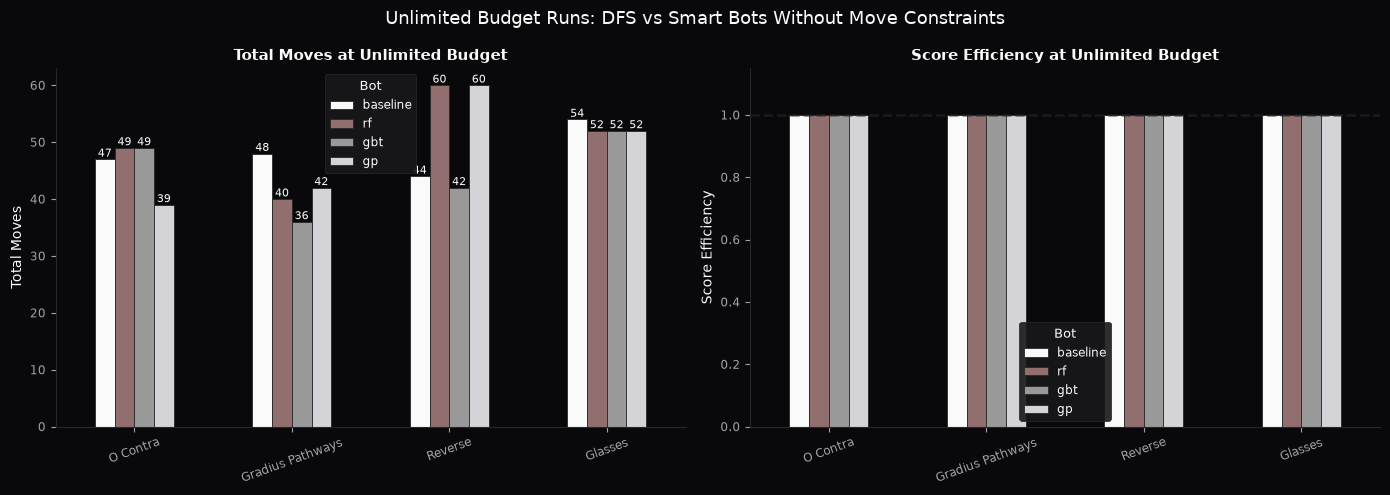


Unlimited run summary:
            maze      bot  score_in_bag  potential_reward  total_moves  score_efficiency  step_efficiency
         Glasses baseline         272.0             272.0           54               1.0         5.037037
         Glasses      gbt         272.0             272.0           52               1.0         5.230769
         Glasses       gp         272.0             272.0           52               1.0         5.230769
         Glasses       rf         272.0             272.0           52               1.0         5.230769
Gradius Pathways baseline         232.0             232.0           48               1.0         4.833333
Gradius Pathways      gbt         232.0             232.0           36               1.0         6.444444
Gradius Pathways       gp         232.0             232.0           42               1.0         5.523810
Gradius Pathways       rf         232.0             232.0           40               1.0         5.800000
        O Contra basel

In [32]:
inf_df = metrics_df[metrics_df["max_moves"].isna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total moves per bot per maze
pivot_moves = inf_df.pivot_table(index="maze", columns="bot", values="total_moves")
pivot_moves = pivot_moves.reindex(MAZE_ORDER)[[b for b in BOT_ORDER if b in pivot_moves.columns]]
pivot_moves.plot(
    kind="bar", ax=axes[0], rot=20,
    color=[PALETTE[b] for b in BOT_ORDER if b in pivot_moves.columns],
    edgecolor=style.BORDER,
)
axes[0].set_title("Total Moves at Unlimited Budget")
axes[0].set_xlabel("")
axes[0].set_ylabel("Total Moves")
axes[0].legend(title="Bot")
for p in axes[0].patches:
    axes[0].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=8, color=style.TEXT,
    )

# Score efficiency, should all be 1.0
pivot_eff = inf_df.pivot_table(index="maze", columns="bot", values="score_efficiency")
pivot_eff = pivot_eff.reindex(MAZE_ORDER)[[b for b in BOT_ORDER if b in pivot_eff.columns]]
pivot_eff.plot(
    kind="bar", ax=axes[1], rot=20,
    color=[PALETTE[b] for b in BOT_ORDER if b in pivot_eff.columns],
    ylim=(0, 1.15),
    edgecolor=style.BORDER,
)
axes[1].axhline(1.0, color=style.BORDER, linestyle="--", alpha=0.6)
axes[1].set_title("Score Efficiency at Unlimited Budget")
axes[1].set_xlabel("")
axes[1].set_ylabel("Score Efficiency")
axes[1].legend(title="Bot")

fig.suptitle("Unlimited Budget Runs: DFS vs Smart Bots Without Move Constraints", fontsize=13)
plt.tight_layout()
plt.savefig(OUT / "unlimited-budget-runs-dfs-vs-smart-bots.svg")
plt.show()

print("\nUnlimited run summary:")
print(
    inf_df[["maze", "bot", "score_in_bag", "potential_reward", "total_moves", "score_efficiency", "step_efficiency"]]
    .sort_values(["maze", "bot"])
    .to_string(index=False)
)

#### Conclusion

Without a move budget, all bots achieve **score_efficiency = 1.0 on every maze**, including `Reverse` maze, where RF and GP lose 2 points at every finite budget. This confirms that the `Reverse` maze loss is a budget artefact: given enough moves, every bot eventually reaches the missed collectible.

The story shifts entirely to **total moves used**, and the results are maze-dependent:

- **`Gradius Pathways`**: GBT is the most move-efficient (36 moves), then RF (40), GP (42), and DFS last (48). GBT's frontier scoring traverses `Gradius` in a near-optimal order with 12 fewer moves than DFS to collect the same 232 points. This is the clearest evidence that the ML scoring adds genuine value beyond DFS.
- **`Glasses`**: all smart bots use 52 moves; DFS uses 54. A small but consistent 2-move advantage for smart bots.
- **`O Contra`**: DFS (47 moves) outperforms GBT (49) and RF (49). GP is most efficient at 39 moves. Smart bots its frontier-hopping costs extra moves on `O Contra` because the high-scored tiles are spatially scattered where the model's predictions create backtracking.
- **`Reverse`**: DFS (44 moves) and GBT (42 moves) are efficient; GP and RF use 60 moves. Without a budget to force prioritisation, GP's UCB exploration and RF's frontier-hopping keep revisiting distant tiles long after the reward is secured. This is the sharpest illustration of the **smart bots its exploration overhead**: 16+ extra moves for identical reward.

**Key limitation**: distance-aware scoring (`reward / distance`) improves reward ordering but does not optimise for spatial compactness of the traversal path. On mazes where the reward layout aligns with the model its predictions (ex: `Gradius`, `Glasses`), smart bots use fewer moves. On mazes where it does not (ex: `O Contra` for RF/GBT, `Reverse` for GP/RF), they backtrack more than DFS.

## Final Conclusions

### The crossover story: tight budgets reveal the smart bots' advantage

Across budgets 20–42 on four held-out mazes, a consistent pattern emerges: **smart bots dominate at tight budgets; the advantage narrows as budget increases; DFS becomes fully competitive at budget 38+.**

**At tight budgets (20–28):**
- GBT and RF maintain score_efficiency ~1.0 on `Glasses` and `Gradius` from budget 20; baseline scores as low as 0.60 (`Glasses`) and 0.66 (`Gradius`).
- GP achieves 1.0 on O `Contra` at every budget being the only bot to do so.
- Average advantage of smart bots over baseline is ~15–25% at the tightest constraint.

**Through the middle range (30–36):**
- Baseline improves steadily as its fixed DFS traversal order eventually covers high-value tiles.
- Smart bots plateau at or near 1.0 on most mazes meaning the gap narrows.
- `O Contra` is the counter-case where DFS reaches 1.0 at budget 36 while RF and GBT don't until budget 38. DFS its traversal order coincidentally visits collectibles in the right sequence on this maze.

**At loose budgets (38+):**
- All bots converge to 1.0 on all mazes (except the structural `Reverse` maze outlier for RF/GP at finite budgets).
- The budget is no longer a binding constraint and reward-ordering advantage disappears.

### The unlimited run reveals move efficiency and its limits

Without a move constraint, **all bots collect 100% reward** where the `Reverse` maze its 2-point loss vanishes, confirming it is a budget artefact. The differentiator becomes total moves:

| Maze | DFS | GBT | RF | GP |
|---|---|---|---|---|
| `Gradius Pathways` | 48 | **36** | 40 | 42 |
| `Glasses` | 54 | 52 | 52 | 52 |
| `O Contra` | 47 | 49 | 49 | **39** |
| `Reverse` | 44 | **42** | 60 | 60 |

GBT uses 12 fewer moves than DFS on `Gradius` and equals or beats DFS on every other maze. GP and RF use 60 moves on `Reverse` which is 16 more than DFS mainly caused due to frontier-hopping that revisits distant tiles without additional reward gain.

**Core limitation of distance-aware scoring**: `reward / distance` improves reward ordering but does not minimise the traversal path its spatial compactness. Where reward aligns with predictions (`Gradius`, `Glasses`), smart bots are more move-efficient. Where it doesn't (`O Contra` for RF/GBT, `Reverse` for GP/RF), they backtrack more than DFS without budget pressure.

### Practical recommendations

| Scenario | Best choice |
|---|---|
| Budget <= 28 | **GBT or GP** at 15–25% above baseline on `Glasses`/`Gradius` |
| Budget 30–36 | **Smart bots** still collect more reward on most mazes |
| Budget >= 38 | Any bot, all are equivalent; DFS is simpler |
| Unlimited | **GBT** is the most move-efficient on 3/4 mazes; avoid RF/GP on `Reverse`-like mazes |

### What the RF model learned (and its limits)

`neighbor_reward_mean` (importance ~0.53) is the dominant feature where reward is spatially clustered and adjacent tile values predict the target tile well. This signal generalises to `Gradius` and `Glasses` but fails on `O Contra` and `Reverse` where the clustering pattern differs from the training distribution. Training on ~130 rows across 7 mazes is sufficient to find the spatial clustering signal but not to generalise perfectly across all maze topologies.